# Checking Holland & Powell (1991)

Functions from EVo (Liggins et al., 2022) have been copied into "function_from_other_tools.py" to allow comparison.

## Python set-up

In [4]:
import pandas as pd
import numpy as np
import VolFe as vf
import math
import matplotlib.pyplot as plt
import function_from_other_tools as of

## Models for fugacity coefficient of H2O

### 'Holland91' Holland & Powell (1991) CMP 109:265-273

Comparison with results from EVo (Liggins et al., 2022) - values match perfectly.

In [2]:
# Conditions
PT = {"P":1000.} # bar
PT["T"]=1200. # C

In [5]:
# EVo
species_list = ["H2O"]
of.find_Y(PT['P'], PT["T"]+273.15, species_list)

(0.9988859662849531, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)

In [6]:
# VolFe
my_models = [["y_H2O", "Holland91"]]
my_models = vf.make_df_and_add_model_defaults(my_models)
vf.y_H2O(PT,models=my_models)

0.9988859662849531

Comparing to Figure 2a in the figure (only valid for T>673)

In [70]:
my_models = [["y_H2O", "Holland91"]]
my_models = vf.make_df_and_add_model_defaults(my_models)

results = pd.DataFrame([["P (kbar)", "T (C)", "V (kJ_kbar)"]])

for P in [1,2,3,5,7,10,20,50]: #  kbar
    PT = {'P':P*1000.}
    if P == 1:
        end = 810
    else:
        end = 1010
    for T in range(100,end,10):
        PT['T'] = T
        V = vf.gas_molar_volume('H2O', PT, my_models)
        results1 = pd.DataFrame([[P, T, V]])
        results = pd.concat([results, results1])
new_header = results.iloc[0]
results = results[1:] #take the data less the header row
results.columns = new_header #set the header row as the df header
results.reset_index(drop=True)
vH2O = results


(1.0, 8.0)

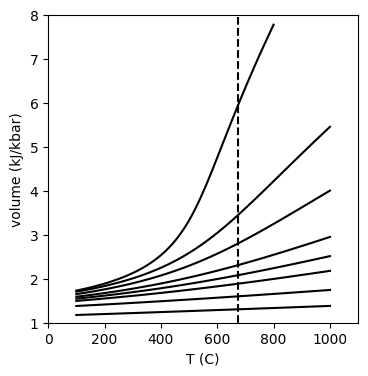

In [72]:
fig, (ax1) = plt.subplots(1, 1, figsize=(4,4))

data = vH2O

# Plotting results
for P in [1,2,3,5,7,10,20,50]:
    data1 = data[data['P (kbar)']==P]
    ax1.plot(data1['T (C)'], data1['V (kJ_kbar)'], '-k')
ax1.plot([673,673],[0,9], '--k')

ax1.set_xlabel('T (C)')
ax1.set_ylabel('volume (kJ/kbar)')
ax1.set_xlim(0,1100)
ax1.set_ylim(1,8)

## Models for fugacity coefficient of CO2

### 'Holland91' Holland & Powell (1991) CMP 109:265-273 10.1007/BF00306484

Comparison with results from EVo (Liggins et al., 2022) - values match perfectly.

In [2]:
# Conditions
PT = {"P":1000.} # bar
PT["T"]=1200. # C

In [3]:
# EVo
species_list = ["CO2"]
of.find_Y(PT['P'], PT["T"]+273.15, species_list)

(0, 0, 0, 0, 1.301912410138897, 0, 0, 0, 0, 0, 0)

In [4]:
# VolFe
my_models = [["y_CO2", "Holland91_eq8_tab1"]]
my_models = vf.make_df_and_add_model_defaults(my_models)
vf.y_CO2(PT,models=my_models)

1.301912410138897

This is the value using eq. (4, A1-3) and parameters in Table 1 (i.e., same equations as H2O)

In [5]:
# VolFe
my_models = [["y_CO2", "Holland91_eq4,A1-3_tab1"]]
my_models = vf.make_df_and_add_model_defaults(my_models)
vf.y_CO2(PT,models=my_models)

1.30988056350442

This is the value using eq (8,9) and parameters in Table 2.

In [6]:
# VolFe
my_models = [["y_CO2", "Holland91_eq8,9_tab2"]]
my_models = vf.make_df_and_add_model_defaults(my_models)
vf.y_CO2(PT,models=my_models)

1.172068398514754

The 2nd value in the list below is "b" - the only one that matches the text saying "b = 3.7852 kJ/kbar" is using eq (9) and Table 2

In [79]:
my_models = [["y_CO2", "Holland91_eq8_tab1"]]
my_models = vf.make_df_and_add_model_defaults(my_models)
vf.parameters_Holland91('CO2',PT,my_models)

(-161.50432712267502, 3.057, -0.11293268420499998, -0.0016088280999999992, 5.0)

In [80]:
my_models = [["y_CO2", "Holland91_eq4,A1-3_tab1"]]
my_models = vf.make_df_and_add_model_defaults(my_models)
vf.parameters_Holland91('CO2',PT,my_models)

(-161.50432712267502, 3.057, -0.11293268420499998, -0.0016088280999999992, 5.0)

In [81]:
my_models = [["y_CO2", "Holland91_eq8,9_tab2"]]
my_models = vf.make_df_and_add_model_defaults(my_models)
vf.parameters_Holland91('CO2',PT,my_models)

(1115.3150702022674,
 3.785191926829268,
 -0.33217869461841454,
 0.016035811460330052,
 '')

Comparison to Figure 7 - matches eq (4,A1-3) using Table 1

In [82]:
my_models = [["y_CO2", "Holland91_eq4,A1-3_tab1"]]
my_models = vf.make_df_and_add_model_defaults(my_models)

results = pd.DataFrame([["P (kbar)", "T (C)", "V (kJ_kbar)"]])

for P in [1,2,4,6,8]: #  kbar
    PT = {'P':P*1000.}
    for T in range(100,1210,10):
        PT['T'] = T
        V = vf.gas_molar_volume('CO2', PT, my_models)
        results1 = pd.DataFrame([[P, T, V]])
        results = pd.concat([results, results1])
new_header = results.iloc[0]
results = results[1:] #take the data less the header row
results.columns = new_header #set the header row as the df header
results.reset_index(drop=True)
vCO2_1 = results

In [83]:
my_models = [["y_CO2", "Holland91_eq8_tab1"]]
my_models = vf.make_df_and_add_model_defaults(my_models)

results = pd.DataFrame([["P (kbar)", "T (C)", "V (kJ_kbar)"]])
for P in [1,2,4,6,8]: #  kbar
    PT = {'P':P*1000.}
    for T in range(100,1210,10):
        PT['T'] = T
        V = vf.gas_molar_volume('CO2', PT, my_models)
        results1 = pd.DataFrame([[P, T, V]])
        results = pd.concat([results, results1])
new_header = results.iloc[0]
results = results[1:] #take the data less the header row
results.columns = new_header #set the header row as the df header
results.reset_index(drop=True)
vCO2_2 = results

In [84]:
my_models = [["y_CO2", "Holland91_eq8,9_tab2"]]
my_models = vf.make_df_and_add_model_defaults(my_models)

results = pd.DataFrame([["P (kbar)", "T (C)", "V (kJ_kbar)"]])

for P in [1,2,4,6,8]: #  kbar
    PT = {'P':P*1000.}
    for T in range(100,1210,10):
        PT['T'] = T
        V = vf.gas_molar_volume('CO2', PT, my_models)
        results1 = pd.DataFrame([[P, T, V]])
        results = pd.concat([results, results1])
new_header = results.iloc[0]
results = results[1:] #take the data less the header row
results.columns = new_header #set the header row as the df header
results.reset_index(drop=True)
vCO2_3 = results

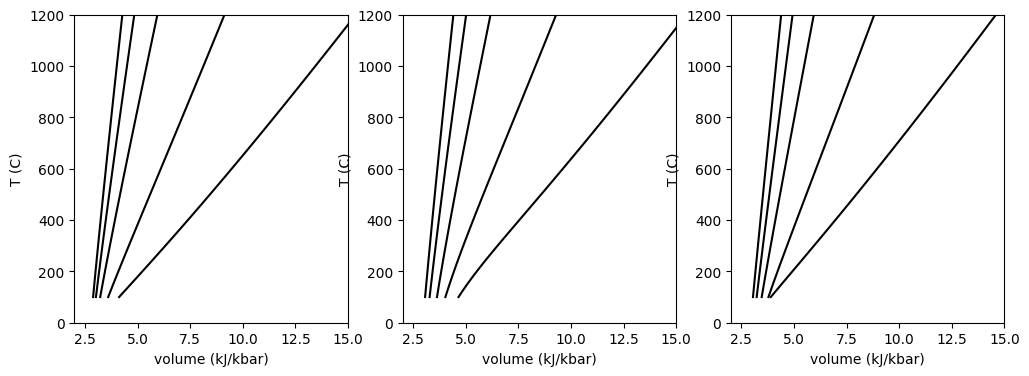

In [78]:
fig, (ax1,ax2,ax3) = plt.subplots(1, 3, figsize=(12,4))

n=0
for x in [vCO2_1,vCO2_2,vCO2_3]:
    data = x
    n = n+1
    if n == 1:
        axn = ax1
    elif n == 2:
        axn = ax2
    if n == 3:
        axn = ax3
    for P in [1,2,4,6,8]:
        data1 = data[data['P (kbar)']==P]
        axn.plot(data1['V (kJ_kbar)'], data1['T (C)'], '-k')

    axn.set_ylabel('T (C)')
    axn.set_xlabel('volume (kJ/kbar)')
    axn.set_ylim(0,1200)
    axn.set_xlim(2,15)

In [102]:
my_models = [["y_CO", "Holland91_eq8,9_tab2"]]
my_models = vf.make_df_and_add_model_defaults(my_models)

results = pd.DataFrame([["P (kbar)", "T (C)", "V (kJ_kbar)"]])

for P in [1,2,4,6,10]: #  kbar
    PT = {'P':P*1000.}
    for T in range(200,1210,10):
        PT['T'] = T
        V = vf.gas_molar_volume('CO', PT, my_models)
        results1 = pd.DataFrame([[P, T, V]])
        results = pd.concat([results, results1])
new_header = results.iloc[0]
results = results[1:] #take the data less the header row
results.columns = new_header #set the header row as the df header
results.reset_index(drop=True)
vCO = results

In [103]:
my_models = [["y_CH4", "Holland91_eq8,9_tab2"]]
my_models = vf.make_df_and_add_model_defaults(my_models)

results = pd.DataFrame([["P (kbar)", "T (C)", "V (kJ_kbar)"]])

for P in [1,2,4,6,10]: #  kbar
    PT = {'P':P*1000.}
    for T in range(200,1210,10):
        PT['T'] = T
        V = vf.gas_molar_volume('CH4', PT, my_models)
        results1 = pd.DataFrame([[P, T, V]])
        results = pd.concat([results, results1])
new_header = results.iloc[0]
results = results[1:] #take the data less the header row
results.columns = new_header #set the header row as the df header
results.reset_index(drop=True)
vCH4 = results

In [105]:
my_models = [["y_H2", "Holland91_eq8,9_tab2"]]
my_models = vf.make_df_and_add_model_defaults(my_models)

results = pd.DataFrame([["P (kbar)", "T (C)", "V (kJ_kbar)"]])

for P in [0.5,1,1.8,5,10]: #  kbar
    PT = {'P':P*1000.}
    for T in range(200,1010,10):
        PT['T'] = T
        V = vf.gas_molar_volume('H2', PT, my_models)
        results1 = pd.DataFrame([[P, T, V]])
        results = pd.concat([results, results1])
new_header = results.iloc[0]
results = results[1:] #take the data less the header row
results.columns = new_header #set the header row as the df header
results.reset_index(drop=True)
vH2 = results

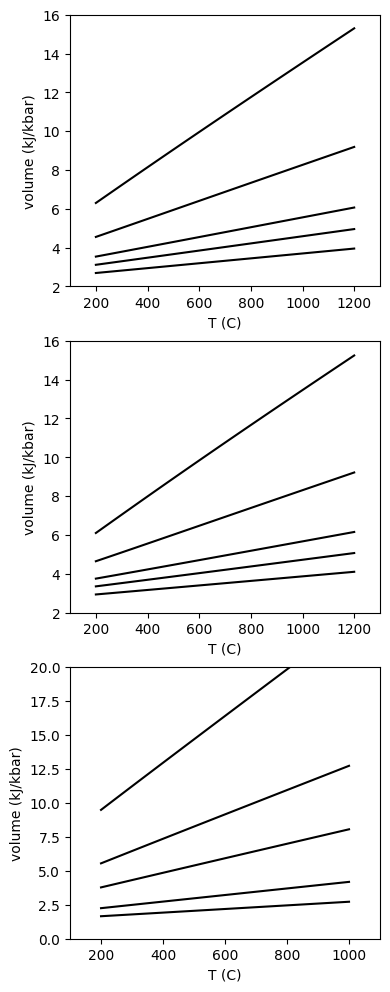

In [106]:
fig, (ax1,ax2,ax3) = plt.subplots(3, 1, figsize=(4,12))

n=0
for x in [vCO,vCH4,vH2]:
    data = x
    n = n+1
    if n == 1:
        axn = ax1
        axn.set_xlim(100,1300)
        axn.set_ylim(2,16)
    elif n == 2:
        axn = ax2       
        axn.set_xlim(100,1300)
        axn.set_ylim(2,16)
    if n in [1,2]:
        for P in [1,2,4,6,10]:
            data1 = data[data['P (kbar)']==P]
            axn.plot(data1['T (C)'], data1['V (kJ_kbar)'], '-k')
    if n == 3:
        axn = ax3
        axn.set_xlim(100,1100)
        axn.set_ylim(0,20)
        for P in [0.5,1,1.8,5,10]:
            data1 = data[data['P (kbar)']==P]
            axn.plot(data1['T (C)'], data1['V (kJ_kbar)'], '-k')


    axn.set_xlabel('T (C)')
    axn.set_ylabel('volume (kJ/kbar)')
